# MODELO DE CLASIFICACIÓN DE IMAGENES PARA DETERMINAR NEUMONIA EN PACIENTES CON COVID 19 USANDO REDES NEURONALES CONVOLUCIONALES

## DATASET  [KAGGLE](https://www.kaggle.com/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/data)

## IMPORTAMOS LIBRERIAS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CARGAMOS PATH DE IMAGENES

In [3]:
import os
BASE_DIR = '/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR,'validation')
TEST_DIR = os.path.join(BASE_DIR,'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/train
/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/validation
/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/test


## 1 -CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE NORMAL Y PNEUMONIA

In [4]:
C1 = 'NORMAL'
C2 = 'PNEUMONIA'

In [5]:
train_c1_dir = os.path.join(TRAIN_DIR, C1)
train_c2_dir = os.path.join(TRAIN_DIR, C2)

validation_c1_dir = os.path.join(VALIDATION_DIR, C1)
validation_c2_dir = os.path.join(VALIDATION_DIR, C2)

test_c1_dir = os.path.join(TEST_DIR, C1)
test_c2_dir = os.path.join(TEST_DIR, C2)

print(train_c1_dir)
print(train_c2_dir)
print(validation_c1_dir)
print(validation_c2_dir)
print(test_c1_dir)
print(test_c2_dir)

/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/train/NORMAL
/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/train/PNEUMONIA
/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/validation/NORMAL
/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/validation/PNEUMONIA
/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/test/NORMAL
/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/test/PNEUMONIA


# MOSTRAMOS UNA IMAGEN

In [8]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def mostrar_imagenes_aleatorias(directorio, num_imagenes=5):
    # Obtener lista de archivos de imagen en el directorio
    imagenes = os.listdir(directorio)

    # Filtrar archivos para obtener solo las imágenes (por ejemplo, con extensiones jpg o png)
    imagenes = [img for img in imagenes if img.endswith(('.jpg', '.jpeg', '.png'))]

    # Seleccionar imágenes aleatorias
    imagenes_aleatorias = random.sample(imagenes, min(num_imagenes, len(imagenes)))

    # Mostrar las imágenes seleccionadas
    for img_name in imagenes_aleatorias:
        img_path = os.path.join(directorio, img_name)
        img = mpimg.imread(img_path)

        plt.figure()
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')  # Ocultar los ejes
        plt.show()

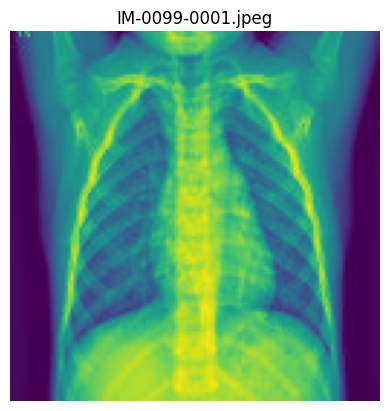

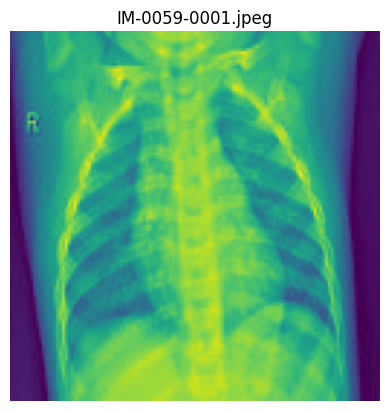

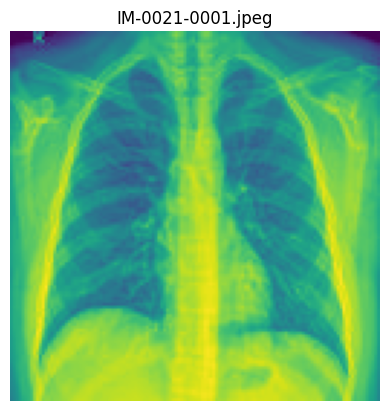

In [9]:
mostrar_imagenes_aleatorias(train_c1_dir,3)

# Mostramos que cantidades de archivos hay en cada carpeta

In [10]:
dataset_dir = [train_c1_dir,train_c2_dir,validation_c1_dir,validation_c2_dir,test_c1_dir,test_c2_dir]
for img_dir in dataset_dir:
  print(f" en directorio :{img_dir} hay {len(os.listdir(img_dir))} imagenes")

 en directorio :/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/train/NORMAL hay 64 imagenes
 en directorio :/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/train/PNEUMONIA hay 63 imagenes
 en directorio :/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/validation/NORMAL hay 17 imagenes
 en directorio :/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/validation/PNEUMONIA hay 17 imagenes
 en directorio :/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/test/NORMAL hay 3 imagenes
 en directorio :/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/test/PNEUMONIA hay 3 imagenes


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [11]:
import tensorflow as tf
print(tf.__version__)

2.19.0


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS CON DATA AUGMENTATION

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [13]:
training_set = train_data.flow_from_directory(
    TRAIN_DIR,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)
validation_set = train_data.flow_from_directory(
    VALIDATION_DIR,
    target_size=(64,64),
    batch_size=20,
    class_mode='binary'
)
test_set = train_data.flow_from_directory(
    TEST_DIR,
    target_size=(64,64),
    class_mode='binary'
)

Found 126 images belonging to 2 classes.
Found 34 images belonging to 2 classes.
Found 6 images belonging to 2 classes.


# CREAMOS MODELO DE RED NEURONAL CONVOLUCIONAL

In [14]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

modelo = Sequential()
modelo.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Conv2D(32,(3,3),activation='relu'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Flatten())
modelo.add(Dense(128,activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(1,activation='sigmoid'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
modelo.compile(loss="binary_crossentropy",
               optimizer='adam',
               metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [22]:
history = modelo.fit(training_set,epochs=3,batch_size=100,validation_data=validation_set)

Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.7851 - loss: 0.4157 - val_accuracy: 0.9118 - val_loss: 0.2288
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.8177 - loss: 0.3914 - val_accuracy: 0.9412 - val_loss: 0.1955
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.8357 - loss: 0.3777 - val_accuracy: 0.8824 - val_loss: 0.2515


# EVALUAMOS EL MODELO

In [23]:
evaluacion = modelo.evaluate(test_set)
print(evaluacion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6667 - loss: 0.3687
[0.3687022626399994, 0.6666666865348816]


# REALIZAMOS PREDICCIÓN DEL MODELO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
predicción :  [[0.]]
es normal


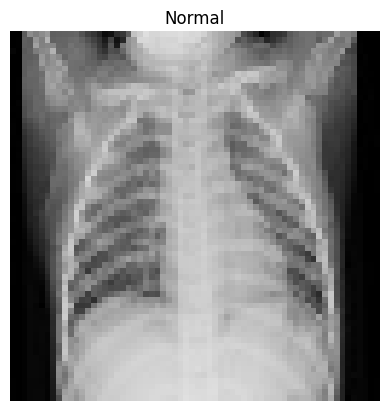

In [24]:
from keras.preprocessing import image
#img_test_normal = '/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/test/NORMAL/NORMAL2-IM-0139-0001.jpeg'
#img_test_pneumonia = '/content/drive/MyDrive/NOTEBOOKS/MODULO6/REDES-NEURONALES-CONVOLUCIONALES/EJERCICIO_REAL_NEUMONIA/dataset_neumonia/test/PNEUMONIA/SARS-10.1148rg.242035193-g04mr34g09c-Fig9c-day27.jpeg'
normal = image.load_img(test_c1_dir + "/NORMAL2-IM-0139-0001.jpeg",target_size=(64,64))
pneumonia = image.load_img(test_c2_dir + "/SARS-10.1148rg.242035193-g04mr34g09c-Fig9c-day27.jpeg",target_size=(64,64))
imagen_prueba = normal

test_image = image.img_to_array(imagen_prueba)
test_image = np.expand_dims(test_image,axis=0)
training_set.class_indices


result = modelo.predict(test_image)
print("predicción : ",result)
if result[0][0] == 0:
  print("es normal")
  plt.imshow(imagen_prueba)
  plt.title('Normal')
  plt.axis('off')
  plt.show()
else:
  print("tiene pneumonia")
  plt.imshow(imagen_prueba)
  plt.title('PNEUMONIA')
  plt.axis('off')
  plt.show()

# GRAFICAMOS ACCURACY Y LOSS

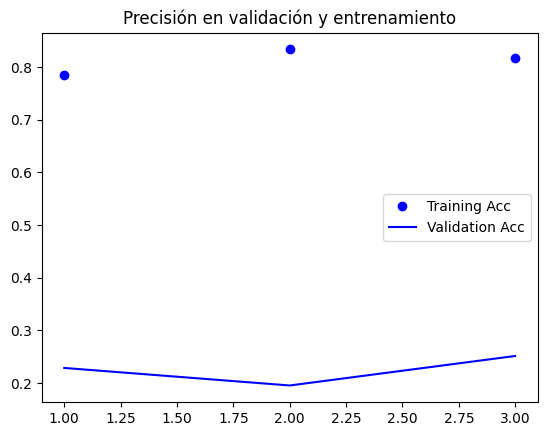

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training Acc')
plt.plot(epochs,val_acc,'b',label='Validation Acc')
plt.title('Precisión en validación y entrenamiento')
plt.legend()
plt.show()

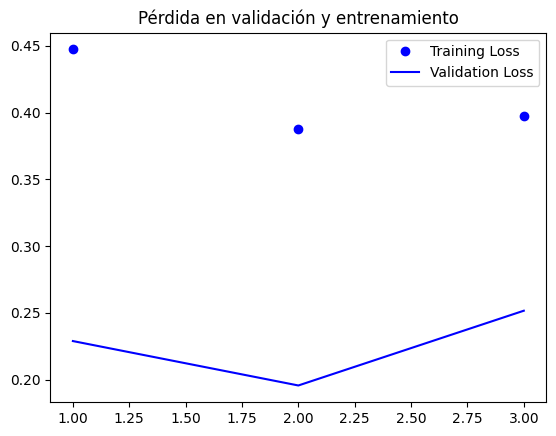

In [26]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'b',label='Validation Loss')
plt.title('Pérdida en validación y entrenamiento')
plt.legend()
plt.show()

In [27]:
modelo.save("cnn_neumonia.keras")